# Project 4 — Notebook 13: City Performance Landscape
### NCR City-Level Fault Ticket Analysis — Volume, MTTR, SLA & Fault Density

---

| | |
|---|---|
| **Scope** | NCR (Region 3) · All reactive tickets (Priority 1–3) · City-level breakdown |
| **Feeds from** | `output/cleaned_fault_ticket.csv` · Project 3 zone benchmarks |
| **Audience** | Operations Leadership / Area Heads |

---

**Questions this notebook answers:**
1. Which cities within each zone are driving zone-level ticket volume — and are they also the underperformers on SLA and MTTR?
2. Does fault density (tickets per site) cluster in specific cities, or is it spread across the zone?
3. Which cities show the worst SLA compliance — and is that consistent with their MTTR profile?
4. Do the zone-level rankings from Project 3 hold at the city level, or are they driven by a small number of high-impact cities?

## 1. Setup
from fault_ticket_plots import plot_city_metric_by_zone

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import ZONE_ORDER, ZONE_PALETTE, SLA_THRESHOLDS
from src.visualization.common_plots import plot_heatmap
from src.visualization.fault_ticket_plots import plot_city_metric_by_zone

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[(df['ZONE'].isin(ZONE_ORDER)) & (df['Priority'] < 4)].copy()
clean   = df_zone[df_zone['Timestamp_Integrity']].copy()

# City order within each zone: sort by ticket volume descending
# Minimum city volume threshold for analysis
MIN_CITY_TICKETS = 50

# Filter to cities with sufficient volume
city_vol = df_zone.groupby(['ZONE','CITY']).size().reset_index(name='Tickets')
valid_cities = city_vol[city_vol['Tickets'] >= MIN_CITY_TICKETS][['ZONE','CITY']]
df_city = df_zone.merge(valid_cities, on=['ZONE','CITY'])
clean_city = clean.merge(valid_cities, on=['ZONE','CITY'])

print(f"✅ {len(df_zone):,} zoned reactive tickets")
print(f"   Zones: {sorted(df_zone['ZONE'].unique())}")
print(f"   Unique cities (all): {df_zone['CITY'].nunique()}")
print(f"   Cities with ≥{MIN_CITY_TICKETS} tickets: {df_city['CITY'].nunique()}")
print(f"   Timestamp-clean tickets: {len(clean_city):,}")
print()
for zone in ZONE_ORDER:
    cities = sorted(df_city[df_city['ZONE']==zone]['CITY'].unique())
    print(f"  {zone}: {len(cities)} cities — {cities}")

✅ 36,907 zoned reactive tickets
   Zones: ['ZONE 1', 'ZONE 2', 'ZONE 3', 'ZONE 4', 'ZONE 5', 'ZONE 6']
   Unique cities (all): 19
   Cities with ≥50 tickets: 17
   Timestamp-clean tickets: 35,523

  ZONE 1: 3 cities — ['CALOOCAN CITY', 'NAVOTAS CITY', 'VALENZUELA CITY']
  ZONE 2: 1 cities — ['QUEZON CITY']
  ZONE 3: 3 cities — ['MALABON CITY', 'MARIKINA CITY', 'RIZAL']
  ZONE 4: 4 cities — ['MANDALUYONG CITY', 'MANILA CITY', 'PASIG CITY', 'SAN JUAN CITY']
  ZONE 5: 3 cities — ['MAKATI CITY', 'PASAY CITY', 'TAGUIG CITY']
  ZONE 6: 3 cities — ['LAS PINAS CITY', 'MUNTINLUPA CITY', 'PARANAQUE CITY']


## 2. City Summary Table — All Zones

In [2]:
# Build city-level summary: volume, SLA, MTTR, fault density, field time
city_summary = (df_city
    .groupby(['ZONE','CITY'])
    .agg(
        Tickets        = ('SLA_Compliant',   'count'),
        SLA_pct        = ('SLA_Compliant',   'mean'),
        Avg_MTTR       = ('OUTAGEDURATION',  'mean'),
        Unique_Sites   = ('SiteName',        'nunique'),
    )
    .reset_index()
)
city_summary['SLA_pct']        *= 100
city_summary['Fault_Density']   = city_summary['Tickets'] / city_summary['Unique_Sites']

# Add NOC time and field time from timestamp-clean tickets
noc_ft = (clean_city
    .groupby(['ZONE','CITY'])
    .agg(
        Avg_NOC_Time   = ('DISPATCH_DELAY_HOURS', 'mean'),
        Avg_Field_Time = ('FIELD_TIME_HOURS',     'mean'),
    )
    .reset_index()
)
city_summary = city_summary.merge(noc_ft, on=['ZONE','CITY'], how='left')

# Zone-level SLA for comparison flag
zone_sla = df_zone.groupby('ZONE')['SLA_Compliant'].mean().mul(100)
city_summary['Zone_SLA'] = city_summary['ZONE'].map(zone_sla)
city_summary['SLA_vs_Zone'] = city_summary['SLA_pct'] - city_summary['Zone_SLA']

# Sort within each zone by ticket volume
city_summary = (city_summary
    .sort_values(['ZONE','Tickets'], ascending=[True, False])
    .reset_index(drop=True)
)

# Print summary per zone
for zone in ZONE_ORDER:
    zc = city_summary[city_summary['ZONE'] == zone]
    print(f"\n{'─'*70}")
    print(f"  {zone}  (zone SLA avg: {zone_sla[zone]:.1f}%)")
    print(f"{'─'*70}")
    print(f"  {'City':<35} {'Tickets':>7} {'Sites':>6} {'Density':>8} "
          f"{'MTTR':>7} {'SLA%':>7} {'vs Zone':>8}")
    for _, row in zc.iterrows():
        flag = '⚠' if row['SLA_vs_Zone'] < -3 else ('✓' if row['SLA_vs_Zone'] > 3 else ' ')
        print(f"  {flag} {row['CITY']:<34} {int(row['Tickets']):>7,} "
              f"{int(row['Unique_Sites']):>6} {row['Fault_Density']:>8.1f} "
              f"{row['Avg_MTTR']:>7.0f}h {row['SLA_pct']:>6.1f}% "
              f"{row['SLA_vs_Zone']:>+7.1f}%")


──────────────────────────────────────────────────────────────────────
  ZONE 1  (zone SLA avg: 83.1%)
──────────────────────────────────────────────────────────────────────
  City                                Tickets  Sites  Density    MTTR    SLA%  vs Zone
    CALOOCAN CITY                        2,282    238      9.6      81h   82.5%    -0.6%
    VALENZUELA CITY                      1,845    195      9.5      44h   83.7%    +0.7%
    NAVOTAS CITY                           179     23      7.8      19h   83.2%    +0.2%

──────────────────────────────────────────────────────────────────────
  ZONE 2  (zone SLA avg: 83.9%)
──────────────────────────────────────────────────────────────────────
  City                                Tickets  Sites  Density    MTTR    SLA%  vs Zone
    QUEZON CITY                          7,307   1043      7.0      51h   83.9%    +0.0%

──────────────────────────────────────────────────────────────────────
  ZONE 3  (zone SLA avg: 80.6%)
────────────────

## 3. Volume & SLA Heatmap — City × Zone

> Cells show SLA compliance (%). City rows ordered by ticket volume within each zone.
> Red = below zone average. Dashed line separates zones.

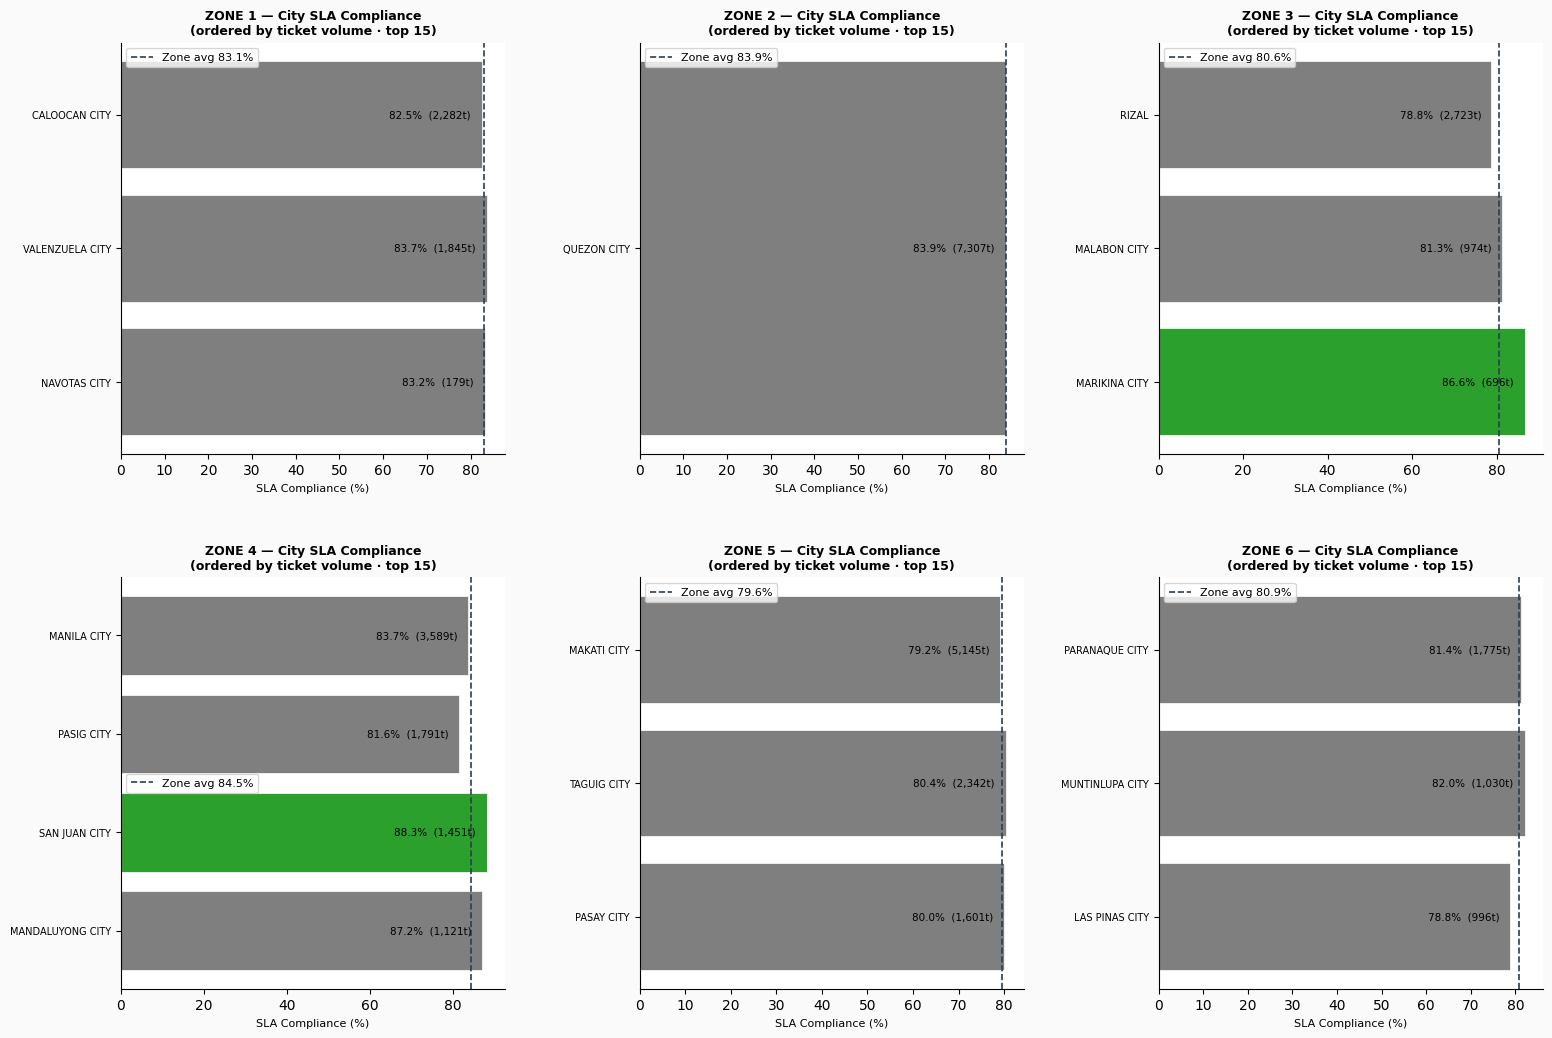


🔴 Red = >3pp below zone avg  |  🟢 Green = >3pp above zone avg  |  ⬜ Grey = within ±3pp


In [3]:
plot_city_metric_by_zone(
    city_summary, ZONE_ORDER,
    value_col    = 'SLA_pct',
    title_tmpl   = '{zone} — City SLA Compliance\n(ordered by ticket volume · top 15)',
    xlabel       = 'SLA Compliance (%)',
    color_fn     = lambda v, avg: ('#d62728' if v < avg - 3 else
                                   '#2ca02c' if v > avg + 3 else '#7f7f7f'),
    ref_line_fn  = lambda zdf: (zone_sla[zdf['ZONE'].iloc[0]],
                                f'Zone avg {zone_sla[zdf["ZONE"].iloc[0]]:.1f}%'),
    annotation_fn        = lambda v, t: f'{v:.1f}%  ({t:,}t)',
    annotation_extra_col = 'Tickets',
    sort_col  = 'Tickets',
    save_path = 'reports/figures/project4_ncr/13_city_sla_by_zone.png',
)
plt.show()
print("\n🔴 Red = >3pp below zone avg  |  🟢 Green = >3pp above zone avg  |  ⬜ Grey = within ±3pp")


## 4. MTTR by City — Identifying Resolution Outliers

> Average MTTR (hours) per city. Cities ordered by volume within zone.
> Zone MTTR average shown as reference line.

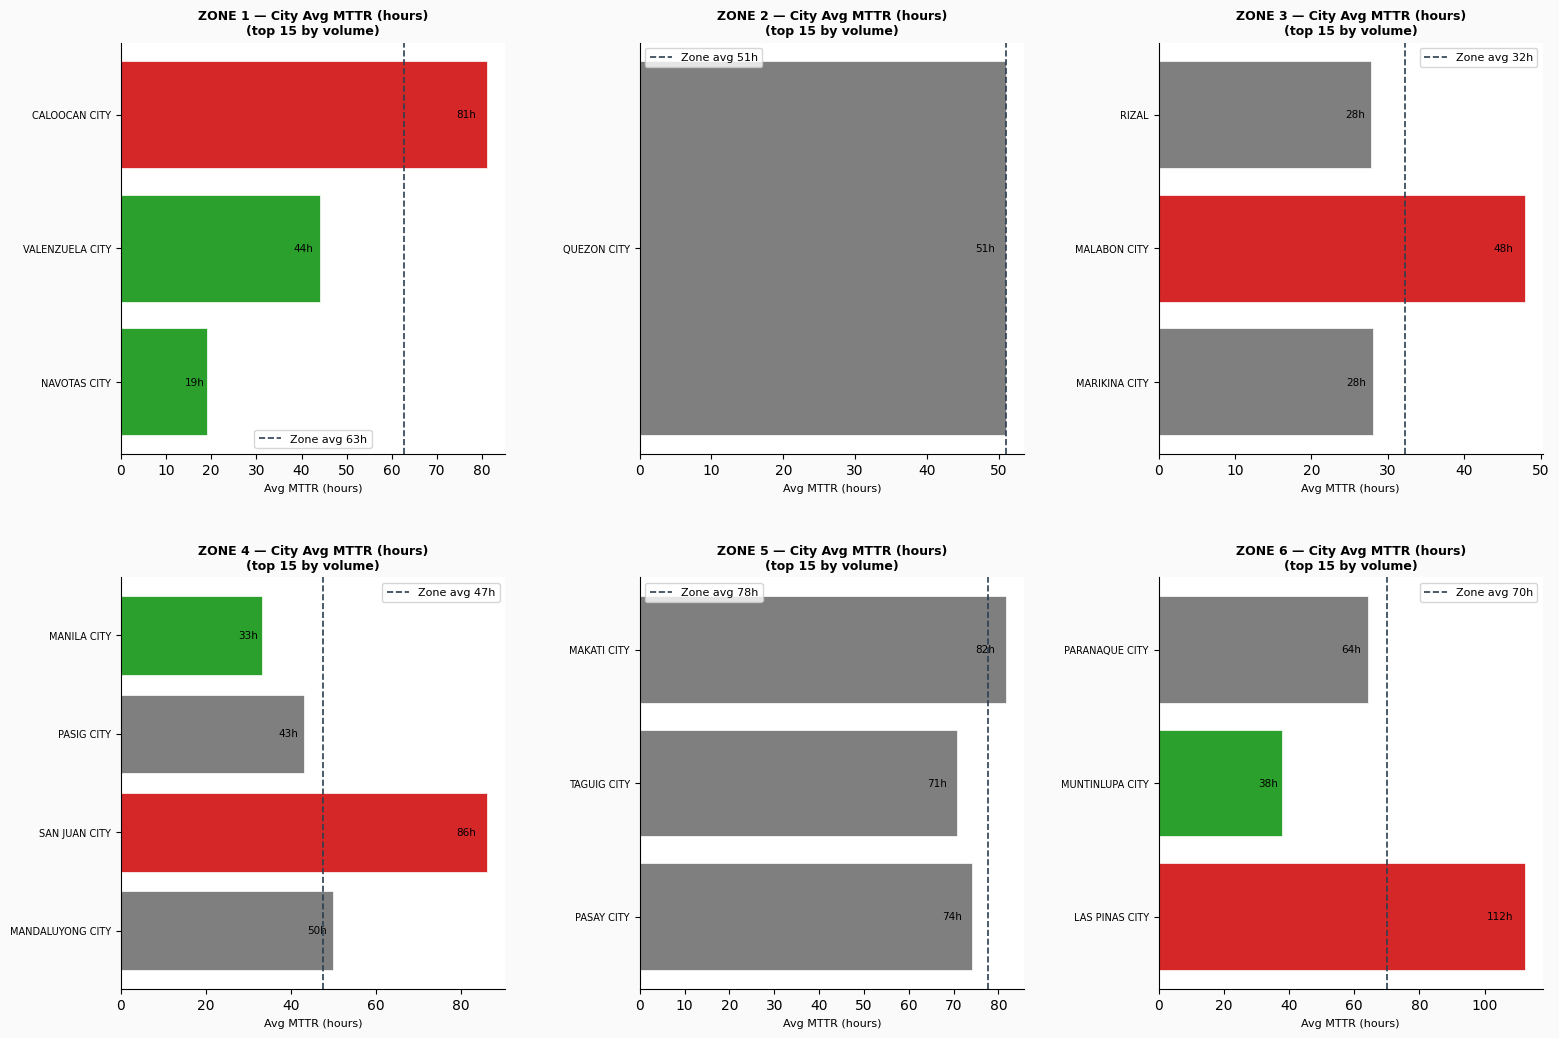


🔴 Red = >25% above zone avg MTTR  |  🟢 Green = >25% below zone avg MTTR


In [4]:
zone_mttr = df_zone.groupby('ZONE')['OUTAGEDURATION'].mean()

plot_city_metric_by_zone(
    city_summary, ZONE_ORDER,
    value_col    = 'Avg_MTTR',
    title_tmpl   = '{zone} — City Avg MTTR (hours)\n(top 15 by volume)',
    xlabel       = 'Avg MTTR (hours)',
    color_fn     = lambda v, avg: ('#d62728' if v > avg * 1.25 else
                                   '#2ca02c' if v < avg * 0.75 else '#7f7f7f'),
    ref_line_fn  = lambda zdf: (zone_mttr[zdf['ZONE'].iloc[0]],
                                f'Zone avg {zone_mttr[zdf["ZONE"].iloc[0]]:.0f}h'),
    annotation_fn = lambda v, _: f'{v:.0f}h',
    sort_col  = 'Tickets',
    save_path = 'reports/figures/project4_ncr/13_city_mttr_by_zone.png',
)
plt.show()
print("\n🔴 Red = >25% above zone avg MTTR  |  🟢 Green = >25% below zone avg MTTR")


## 5. Fault Density by City

> Fault density = tickets per unique site. High density = same infrastructure generating repeated faults.
> This is the leading indicator for preventive maintenance targeting (see Project 5).

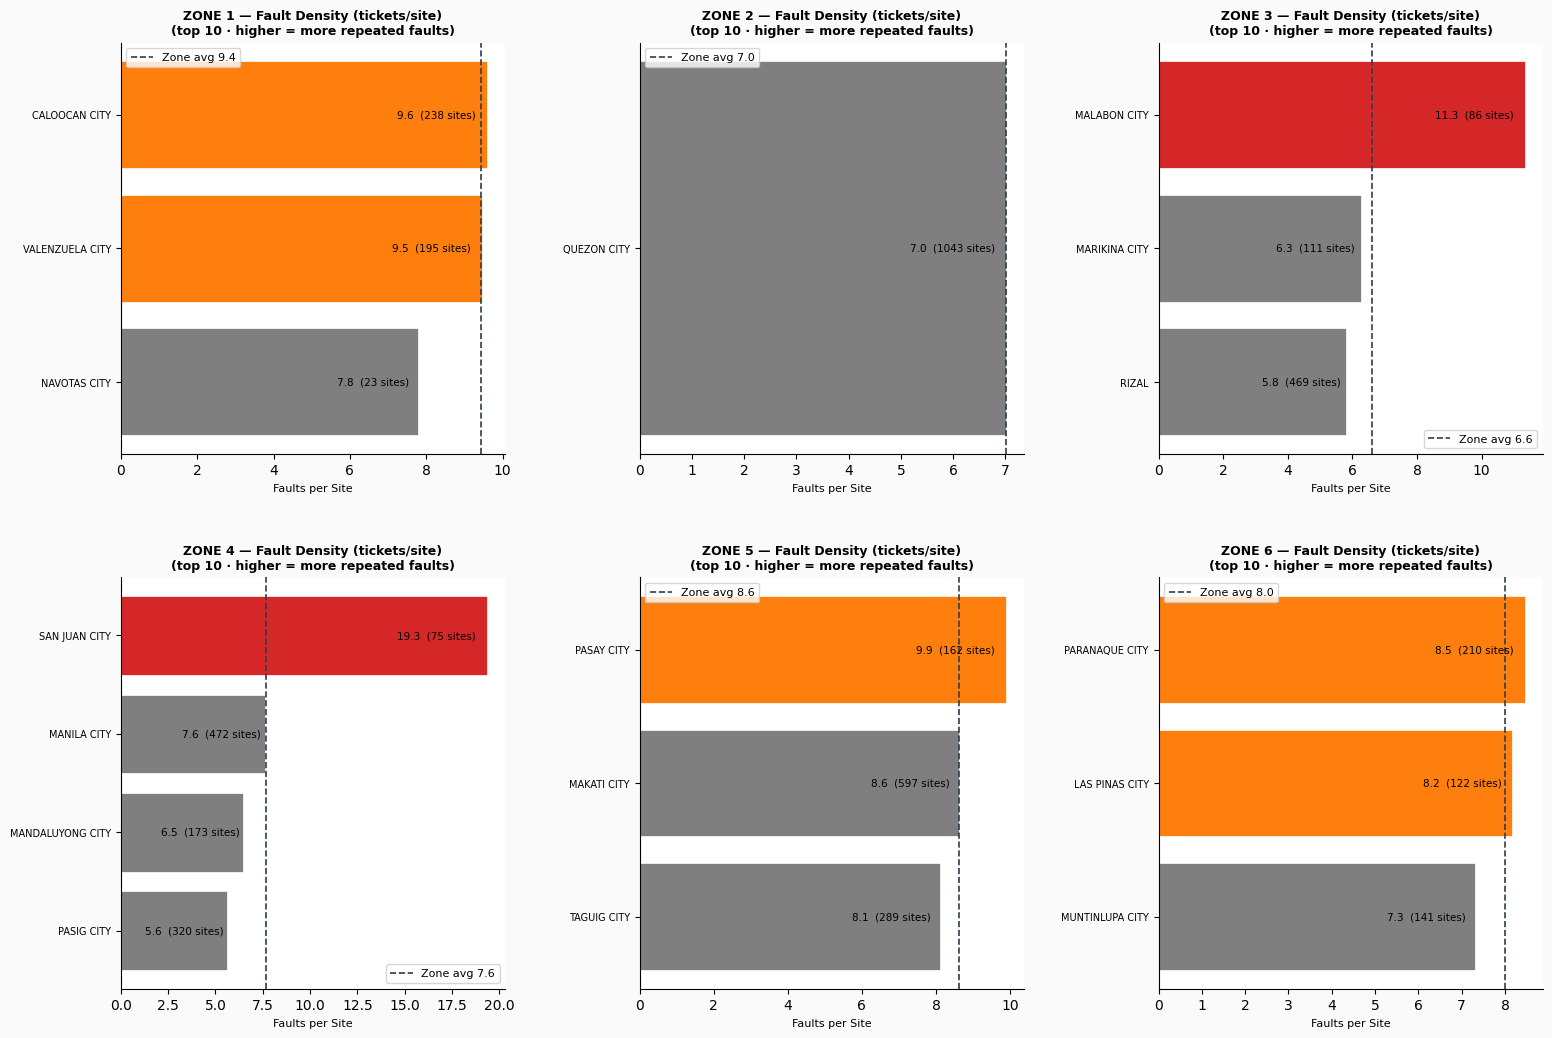

In [5]:
zone_density = (df_zone.groupby('ZONE')
    .apply(lambda z: z['TICKETID'].count() / z['SiteName'].nunique(),
           include_groups=False)
    .rename('Zone_Density'))

plot_city_metric_by_zone(
    city_summary, ZONE_ORDER,
    value_col    = 'Fault_Density',
    title_tmpl   = '{zone} — Fault Density (tickets/site)\n(top 10 · higher = more repeated faults)',
    xlabel       = 'Faults per Site',
    color_fn     = lambda v, avg: ('#d62728' if v > avg * 1.25 else
                                   '#ff7f0e' if v > avg else '#7f7f7f'),
    ref_line_fn  = lambda zdf: (zone_density[zdf['ZONE'].iloc[0]],
                                f'Zone avg {zone_density[zdf["ZONE"].iloc[0]]:.1f}'),
    annotation_fn        = lambda v, s: f'{v:.1f}  ({s} sites)',
    annotation_extra_col = 'Unique_Sites',
    top_n     = 10,
    sort_col  = 'Fault_Density',
    save_path = 'reports/figures/project4_ncr/13_city_fault_density.png',
)
plt.show()


## 6. City Ticket Distribution — Volume & SLA by City Within Each Zone

> Most NCR zones have 3 or fewer cities meeting the ≥50 ticket threshold
> (Zone 2 has only Quezon City; Pateros and Bacoor fall below the volume floor).
> The 'top 3 concentration' framing is trivially 100% for Zone 2 and covers
> all valid cities in most other zones. Instead this section shows the full
> city distribution per zone — ticket volume and SLA compliance side by side —
> so the within-zone spread is visible directly.

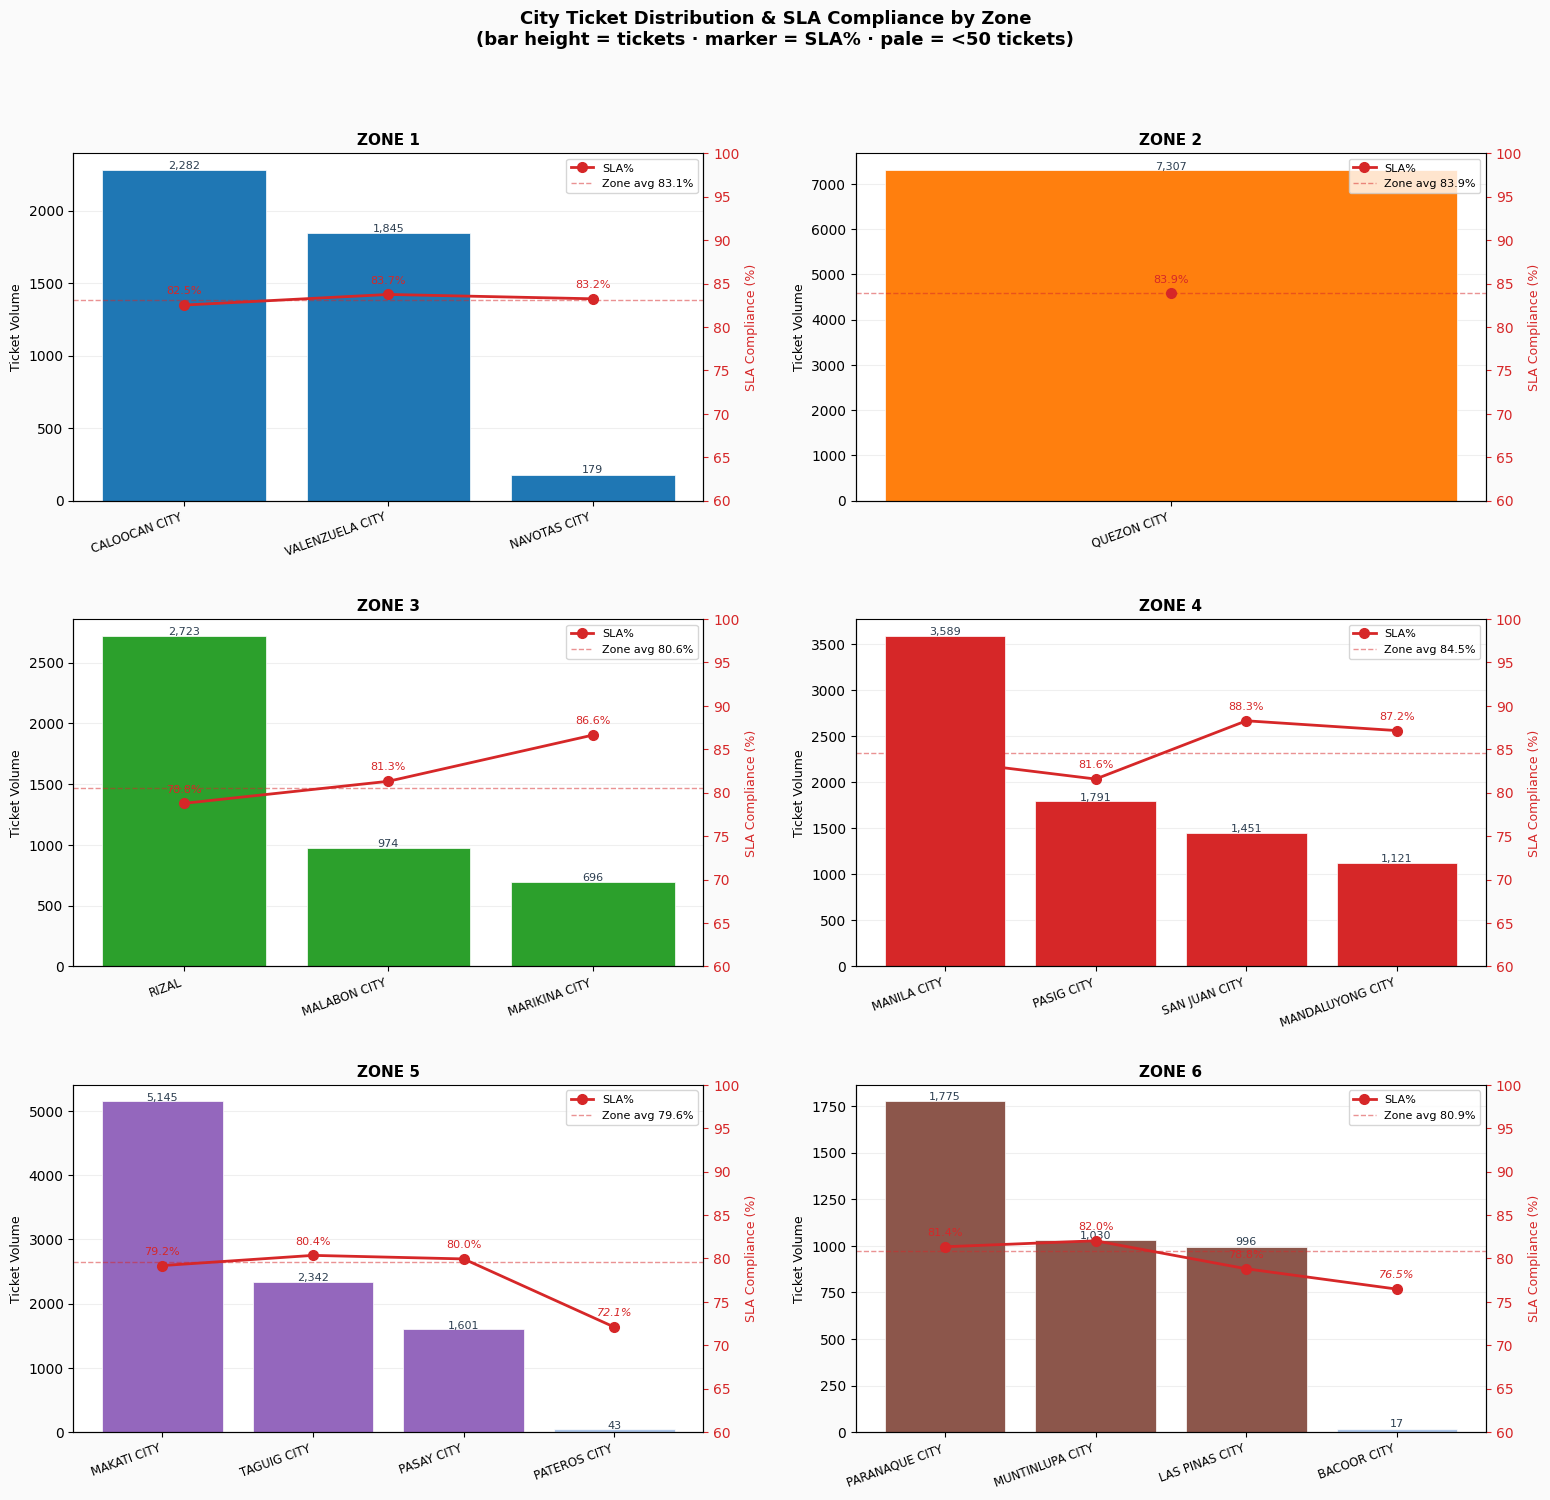

City distribution summary (incl. low-volume cities):

  ZONE 1  (zone SLA: 83.1%)
    CALOOCAN CITY                  2,282 tickets  SLA:  82.5%  MTTR:    81h
    VALENZUELA CITY                1,845 tickets  SLA:  83.7%  MTTR:    44h
    NAVOTAS CITY                     179 tickets  SLA:  83.2%  MTTR:    19h

  ZONE 2  (zone SLA: 83.9%)
    QUEZON CITY                    7,307 tickets  SLA:  83.9%  MTTR:    51h

  ZONE 3  (zone SLA: 80.6%)
    RIZAL                          2,723 tickets  SLA:  78.8%  MTTR:    28h
    MALABON CITY                     974 tickets  SLA:  81.3%  MTTR:    48h
    MARIKINA CITY                    696 tickets  SLA:  86.6%  MTTR:    28h

  ZONE 4  (zone SLA: 84.5%)
    MANILA CITY                    3,589 tickets  SLA:  83.7%  MTTR:    33h
    PASIG CITY                     1,791 tickets  SLA:  81.6%  MTTR:    43h
    SAN JUAN CITY                  1,451 tickets  SLA:  88.3%  MTTR:    86h
    MANDALUYONG CITY               1,121 tickets  SLA:  87.2%  MTTR:   

In [6]:
# City distribution: ticket volume + SLA compliance per city per zone
# All cities including those below MIN_CITY_TICKETS threshold — shown with
# a lighter bar to indicate low volume / less reliable SLA estimate.

# Full city list per zone (from your data)
CITY_ZONE = {
    'ZONE 1': ['CALOOCAN CITY', 'VALENZUELA CITY', 'NAVOTAS CITY'],
    'ZONE 2': ['QUEZON CITY'],
    'ZONE 3': ['MARIKINA CITY', 'MALABON CITY', 'RIZAL'],
    'ZONE 4': ['MANILA CITY', 'PASIG CITY', 'MANDALUYONG CITY', 'SAN JUAN CITY'],
    'ZONE 5': ['MAKATI CITY', 'TAGUIG CITY', 'PASAY CITY', 'PATEROS'],
    'ZONE 6': ['PARANAQUE CITY', 'LAS PINAS CITY', 'MUNTINLUPA CITY', 'BACOOR'],
}

# Build full city stats including low-volume cities
city_all = (df_zone
    .groupby(['ZONE','CITY'])
    .agg(
        Tickets   = ('SLA_Compliant', 'count'),
        SLA_pct   = ('SLA_Compliant', 'mean'),
        Avg_MTTR  = ('OUTAGEDURATION', 'mean'),
    )
    .reset_index()
)
city_all['SLA_pct'] *= 100
city_all['Low_Vol'] = city_all['Tickets'] < MIN_CITY_TICKETS

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('City Ticket Distribution & SLA Compliance by Zone\n'
             '(bar height = tickets · marker = SLA% · pale = <50 tickets)',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax_i, zone in enumerate(ZONE_ORDER):
    ax  = axes[ax_i]
    ax2 = ax.twinx()

    zc  = city_all[city_all['ZONE'] == zone].copy()
    # Sort by volume descending
    zc  = zc.sort_values('Tickets', ascending=False).reset_index(drop=True)

    zone_avg_sla = zone_sla[zone]
    bar_colors   = ['#aec6e8' if lv else ZONE_PALETTE[zone]
                    for lv in zc['Low_Vol']]

    bars = ax.bar(zc['CITY'], zc['Tickets'], color=bar_colors,
                   edgecolor='white', linewidth=0.5, zorder=2)
    for bar, val in zip(bars, zc['Tickets']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontsize=8, color='#2c3e50')

    # SLA line on secondary axis
    ax2.plot(range(len(zc)), zc['SLA_pct'], color='#d62728',
              marker='o', linewidth=2, markersize=7, zorder=3, label='SLA%')
    ax2.axhline(zone_avg_sla, color='#d62728', linestyle='--',
                 linewidth=1, alpha=0.5, label=f'Zone avg {zone_avg_sla:.1f}%')
    for xi, (sla, lv) in enumerate(zip(zc['SLA_pct'], zc['Low_Vol'])):
        ax2.annotate(f'{sla:.1f}%', (xi, sla),
                      xytext=(0, 8), textcoords='offset points',
                      ha='center', fontsize=8, color='#d62728',
                      fontstyle='italic' if lv else 'normal')

    ax.set_title(f'{zone}', fontsize=11, fontweight='bold', pad=6)
    ax.set_ylabel('Ticket Volume', fontsize=9)
    ax.set_xticks(range(len(zc)))
    ax.set_xticklabels(zc['CITY'], rotation=20, ha='right', fontsize=8.5)
    ax2.set_ylabel('SLA Compliance (%)', fontsize=9, color='#d62728')
    ax2.set_ylim(60, 100)
    ax2.tick_params(axis='y', colors='#d62728')
    ax2.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.grid(axis='y', alpha=0.2, zorder=0)

plt.tight_layout(pad=2.5)
plt.savefig('reports/figures/project4_ncr/13_city_distribution.png',
             dpi=150, bbox_inches='tight')
plt.show()

# Print full table
print('City distribution summary (incl. low-volume cities):')
for zone in ZONE_ORDER:
    print(f'\n  {zone}  (zone SLA: {zone_sla[zone]:.1f}%)')
    zc = city_all[city_all['ZONE']==zone].sort_values('Tickets', ascending=False)
    for _, row in zc.iterrows():
        flag = ' ⚠ low vol' if row['Low_Vol'] else ''
        print(f'    {row["CITY"]:<30} {int(row["Tickets"]):>5,} tickets  '
              f'SLA: {row["SLA_pct"]:>5.1f}%  MTTR: {row["Avg_MTTR"]:>5.0f}h{flag}')

## 7. Next Steps

→ **Notebook 14** — City Deep Dive: P3.2 breach concentration by city, NOC endorsement
delay patterns by city, UNKNOWN ticket rates by city, and Zone 5 CBD vs non-CBD field time split.